# Baselines: how well do off-the-shelf models diagnose faults at held-out loads?

Four baselines on the raw sensor channels — majority-class dummy, logistic
regression, random forest and gradient boosting (LightGBM) — scored with
leave-one-load-out (LOLO): each of the four load bins is held out as test
in turn, so every score reflects a load the model never trained on.

**Main findings:** logistic regression wins on pooled macro F1 (0.440),
ahead of LightGBM (0.389), random forest (0.285) and the majority-class
dummy (0.108). Its per-fold macro F1 swings from 0.30 (40% load held out)
to 0.55 (75% load held out), so the pooled number hides real fold-to-fold
spread. None of the four generalise well to an unseen load: the best
model's worst per-class recall is 0.13 (TD), and LightGBM and random forest
both collapse to near-zero recall on at least one class when that load is
held out. Raw-sensor baselines with no load-aware features are not enough;
later notebooks need features that separate the fault signal from the load
shift itself.

**Against the brief's first check:** the brief's first raw-sensor baseline
scored macro F1 0.52, with turbine degradation (TD) recall of 0.00 and a
false alarm rate of 29.8%. Our best model lands lower on macro F1 (0.44 vs
0.52) but higher on TD recall (0.13 vs 0.00) and lower on false alarms
(22.5% vs 29.8%). The gap is material. The first check's code is not in
this repository, so its cause can't be pinned down; the candidates are
(a) channels this project excludes on purpose (Compressor Filter Loss and
Turbine Back Pressure, which are the fault settings themselves, Engine room
Temp., time columns), (b) how rows were binned into loads and whether the
stepped injector run and the reference file were included, and (c) model
settings such as class weights. None of these is added back or tuned here
to chase 0.52: the protocol in `keyframe.splits` is the one every later
score uses, so this 0.44 is the honest starting point.

In [1]:
import lightgbm as lgb
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from keyframe import SEED, evaluate, features, paths

paths.FIGURES.mkdir(parents=True, exist_ok=True)
paths.RESULTS.mkdir(parents=True, exist_ok=True)
paths.PROCESSED.mkdir(parents=True, exist_ok=True)

clean = pd.read_parquet(paths.PROCESSED / "clean.parquet")
FEATURE_COLUMNS = features.raw_sensor_columns(clean)

## The four baselines

Scalers and estimators are fit inside each LOLO fold, never on the pooled
table, so no held-out load leaks into training.

In [2]:
MODEL_FACTORIES = {
    "dummy_majority": lambda: DummyClassifier(strategy="most_frequent"),
    "logistic_regression": lambda: make_pipeline(
        StandardScaler(),
        LogisticRegression(class_weight="balanced", max_iter=2000, random_state=SEED),
    ),
    "random_forest": lambda: RandomForestClassifier(
        n_estimators=300, class_weight="balanced", random_state=SEED
    ),
    "lightgbm": lambda: lgb.LGBMClassifier(class_weight="balanced", random_state=SEED, verbose=-1),
}

## Pooled and per-fold scores for each baseline

In [3]:
predictions_by_model = {
    name: evaluate.lolo_predict(factory, clean, FEATURE_COLUMNS)
    for name, factory in MODEL_FACTORIES.items()
}

summaries = []
for name, predictions in predictions_by_model.items():
    summary = evaluate.summarise(predictions)
    summary.insert(0, "model", name)
    summaries.append(summary)
results = pd.concat(summaries, ignore_index=True)
evaluate.log_results("02_baselines", results)
results

,model,fold,macro_f1,accuracy,false_alarm_rate,worst_recall,worst_recall_class
0,dummy_majority,pooled,0.108197,0.480584,0.000000,0.000000,AC
1,dummy_majority,40,0.149735,0.598309,0.000000,0.000000,AC
2,dummy_majority,60,0.100349,0.430708,0.000000,0.000000,AC
3,dummy_majority,75,0.177442,0.550111,0.000000,0.000000,AC
4,dummy_majority,85,0.093017,0.387062,0.000000,0.000000,AC
5,logistic_regression,pooled,0.439858,0.522500,0.225194,0.127199,TD
6,logistic_regression,40,0.300006,0.636398,0.000125,0.000000,AF
7,logistic_regression,60,0.435900,0.406866,0.536238,0.018141,CW
8,logistic_regression,75,0.550197,0.527237,0.397379,0.000000,AC
9,logistic_regression,85,0.361232,0.545892,0.000696,0.000000,AC


## Which baseline generalises best to an unseen load?

Ranked by pooled macro F1 (the headline target), not accuracy, since the
classes are imbalanced.

In [4]:
pooled = results[results["fold"] == "pooled"].sort_values("macro_f1", ascending=False)
best_model = pooled.iloc[0]["model"]
pooled

,model,fold,macro_f1,accuracy,false_alarm_rate,worst_recall,worst_recall_class
5,logistic_regression,pooled,0.439858,0.522500,0.225194,0.127199,TD
15,lightgbm,pooled,0.389392,0.531622,0.321084,0.002549,TD
10,random_forest,pooled,0.285123,0.535243,0.100630,0.000000,AC
0,dummy_majority,pooled,0.108197,0.480584,0.000000,0.000000,AC


In [5]:
best_predictions = predictions_by_model[best_model]
best_predictions.to_parquet(paths.PROCESSED / "02_best_baseline_predictions.parquet")
best_model

'logistic_regression'

## Per-fold spread: does any model fall apart at a particular load?

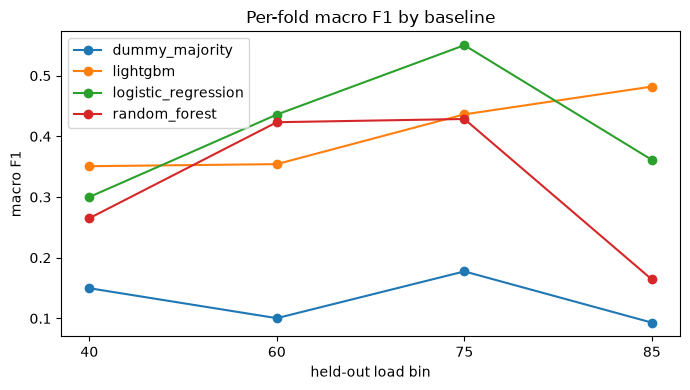

In [6]:
per_fold = results[results["fold"] != "pooled"]
fig, ax = plt.subplots(figsize=(7, 4))
for name, group in per_fold.groupby("model"):
    group = group.sort_values("fold")
    ax.plot(group["fold"].astype(str), group["macro_f1"], marker="o", label=name)
ax.set_xlabel("held-out load bin")
ax.set_ylabel("macro F1")
ax.set_title("Per-fold macro F1 by baseline")
ax.legend()
fig.tight_layout()
fig.savefig(paths.FIGURES / "02_fold_scores.png", dpi=150)
plt.show()

## Confusion matrix of the best baseline

Pooled over all four folds, rows normalised to recall so each row shows
where that class's predictions land.

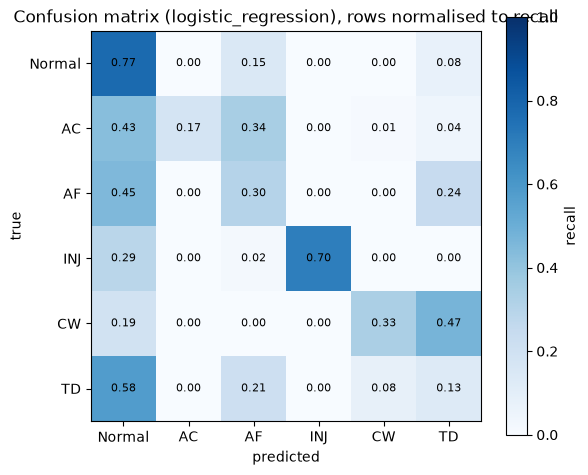

In [7]:
confusion = evaluate.confusion(best_predictions["y_true"], best_predictions["y_pred"])
confusion_recall = confusion.div(confusion.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(confusion_recall, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(evaluate.CLASS_ORDER)), evaluate.CLASS_ORDER)
ax.set_yticks(range(len(evaluate.CLASS_ORDER)), evaluate.CLASS_ORDER)
ax.set_xlabel("predicted")
ax.set_ylabel("true")
ax.set_title(f"Confusion matrix ({best_model}), rows normalised to recall")
for i in range(len(evaluate.CLASS_ORDER)):
    for j in range(len(evaluate.CLASS_ORDER)):
        ax.text(j, i, f"{confusion_recall.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, label="recall")
fig.tight_layout()
fig.savefig(paths.FIGURES / "02_confusion_best.png", dpi=150)
plt.show()

## What this means for the next notebooks

Numbers above are read from the executed run, not tuned to hit a target.

**What the baselines get wrong.** Turbine degradation (TD) is the weakest
class across every baseline: the best model's TD recall is 0.13, and
LightGBM's pooled worst-class recall (also TD) is 0.0025 — the model
almost never calls a TD row correctly once its load is held out. TD has
only three runs in the dataset (`specs/brief.md`), so there is little
signal to generalise from, and 75% load has no TD or cavitation runs at
all, which thins the per-fold evidence further. False alarms are the
other weak spot: logistic regression's pooled false alarm rate is 22.5%,
and it spikes to 53.6% on the 60% load fold and 39.7% on 75%, meaning that
on some loads the model flags more than a third of healthy running as
faulty. Both weaknesses point the same way — raw sensor levels shift with
load, and the model is confusing a load shift for a fault (or a subtle
fault for a load shift) because nothing here separates the two.

**What feature engineering should target.** Healthy-engine residuals
(notebook 03) should attack the false alarm rate directly, since a
reading's deviation from its load-conditioned expectation should not move
just because the load changed. Physics features (turbocharger pressure
ratio, turbine inlet-outlet temperature spread) target TD specifically,
since they encode the turbine behaviour that raw sensor levels alone did
not separate from load. Rolling-window features may help less here since
TD's problem looks like too little data rather than a signal that needs
smoothing, so the ablation table in notebook 03 should watch TD recall and
the false alarm rate, not just pooled macro F1, when judging whether a
feature set earns its place.